# Figure 5 --- Mechanisms


In [45]:
import sys
sys.path.append('../src')

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from tqdm.auto import tqdm

from Config.config import PATHS
from Utils.utils import GetMeasurements
from Utils.interaction import Performer
from Classes.cognitive_model_agents import (
    PayoffM1,
    OnlyAttendanceM1,
    FocalRegionAgent,
    AttendanceM1,
    PayoffICSMM1,
    AttendancePayoffICSMM1,
)

In [ ]:
# Six models from the AIC lattice (no Fairness branch).
lattice_models = [
    PayoffM1,                 # Payoff
    OnlyAttendanceM1,         # Attendance
    FocalRegionAgent,         # ICSM
    AttendanceM1,             # Attendance + Payoff
    PayoffICSMM1,             # Payoff + ICSM
    AttendancePayoffICSMM1,   # Attendance + Payoff + ICSM
]

free_parameters = {
    'inverse_temperature': 8,
    'learning_rate': 0.2,
    'bias': 0.65,
    'forget': 0.8,
    'len_history': 2,
    'delta': 0.2,
    'max_regions': 3,
}

simulation_parameters = {
    'num_rounds': 100,
    'num_episodes': 200,
    'verbose': False
}

list_fixed_parameters = [
    (2, 0.5),
    (3, 1/3), (3, 2/3),
    (4, 1/4), (4, 0.5), (4, 3/4),
]

RUN_SIMULATIONS = False
sim_file = PATHS['simulated_data'] / 'Fig5_lattice_models.csv'

if RUN_SIMULATIONS:
    df_list = []
    for num_agents, threshold in tqdm(list_fixed_parameters, desc='Treatments'):
        fixed_parameters = {
            'num_agents': num_agents,
            'threshold': threshold,
        }
        for model_class in tqdm(
            lattice_models,
            desc=f'{num_agents}P, threshold={threshold:.2f}',
            leave=False,
        ):
            df2 = Performer.sim(
                agent_class=model_class,
                fixed_parameters=fixed_parameters,
                free_parameters=free_parameters,
                simulation_parameters=simulation_parameters,
            )
            df2['model'] = model_class.name()
            df_list.append(df2)

    df2 = pd.concat(df_list, ignore_index=True)
    df2['bounded_score'] = df2['score'] / df2['threshold']
    df2.to_csv(sim_file, index=False)
    print(f'{len(df2):,} rows saved to {sim_file}')
else:
    df2 = pd.read_csv(sim_file)
    print(f'{len(df2):,} rows loaded from {sim_file}')


Treatments:   0%|          | 0/6 [00:00<?, ?it/s]

2P, threshold=0.50:   0%|          | 0/6 [00:00<?, ?it/s]

Payoff-M1:   0%|          | 0/200 [00:00<?, ?it/s]

OnlyAttendance-M1:   0%|          | 0/200 [00:00<?, ?it/s]

ICSM:   0%|          | 0/200 [00:00<?, ?it/s]

...

ICSM:   0%|          | 0/200 [00:00<?, ?it/s]

Attendance-M1:   0%|          | 0/200 [00:00<?, ?it/s]

Payoff+ICSM-M1:   0%|          | 0/200 [00:00<?, ?it/s]

Attendance+Payoff+ICSM-M1:   0%|          | 0/200 [00:00<?, ?it/s]

2,400,000 rows saved to /Users/edgarjoseandradelotero/GitHub/Cognitive_Models_El_Farol_Bar_Problem/data/simulated/Fig5_lattice_models.csv


In [47]:
gm = GetMeasurements(
    data=df2, measures=['bounded_efficiency', 'gini_index'], T=20
)
data = gm.get_measurements()

In [48]:
from Utils.utils import PPT

path_to_data = PATHS['human_data'] / 'multi-player.csv'
data_human = pd.read_csv(path_to_data)
data_human['model'] = data_human.apply(
    lambda row: f"{row['num_players']}-{row['threshold']:.2f}-{row['group']}", axis=1
)

BEST_MODEL_NAME = 'Attendance+Payoff+ICSM-M1'

path_to_data_sim = PATHS['simulated_data'] / f'{BEST_MODEL_NAME}_simulated.csv'
data_sim = pd.read_csv(path_to_data_sim)
data_sim['treatment'] = 'Best fitting model'
data_sim['model'] = BEST_MODEL_NAME

df = PPT.concat_dfs(data_human, data_sim)

plot_df = df.copy()
plot_df['source'] = np.where(
    plot_df['model'] == BEST_MODEL_NAME,
    'Best fitting model',
    'Humans',
)
plot_df['score_norm'] = plot_df['score'] / plot_df['threshold']
plot_df.tail()


,model,treatment,threshold,num_agents,id_sim,id_player,round,decision,score,source,score_norm
194475,Attendance+Payoff+ICSM-M1,Best fitting model,0.5,6,7ca98544-b576-11f1-8c80-839f7e052b57,1,30,0.0,0.0,Best fitting model,0.0
194476,Attendance+Payoff+ICSM-M1,Best fitting model,0.5,6,7ca98544-b576-11f1-8c80-839f7e052b57,2,30,0.0,0.0,Best fitting model,0.0
194477,Attendance+Payoff+ICSM-M1,Best fitting model,0.5,6,7ca98544-b576-11f1-8c80-839f7e052b57,3,30,1.0,1.0,Best fitting model,2.0
194478,Attendance+Payoff+ICSM-M1,Best fitting model,0.5,6,7ca98544-b576-11f1-8c80-839f7e052b57,4,30,0.0,0.0,Best fitting model,0.0
194479,Attendance+Payoff+ICSM-M1,Best fitting model,0.5,6,7ca98544-b576-11f1-8c80-839f7e052b57,5,30,0.0,0.0,Best fitting model,0.0


In [49]:
# Shared colors for panels A, B, and C (node headers).
MODEL_COLORS = {
    'Payoff': '#1f77b4',
    'Attendance': '#ff7f0e',
    'ICSM': '#2ca02c',
    'Attendance + Payoff': '#e377c2',
    'Payoff + ICSM': '#56B4E9',
    'Attendance + Payoff + ICSM': '#D55E00',
}


def _label_color(color):
    from matplotlib.colors import to_rgb
    r, g, b = to_rgb(color)
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
    return '#22333b' if luminance > 0.55 else 'white'
VARIANT = 'M1'
LATTICE = {
    1: [
        ('Payoff', 'Payoff'),
        ('Attendance', 'OnlyAttendance'),
        ('ICSM', 'ICSM'),
    ],
    2: [
        ('Attendance + Payoff', 'Attendance'),
        ('Payoff + ICSM', 'Payoff+ICSM'),
    ],
    3: [
        ('Attendance + Payoff + ICSM', 'Attendance+Payoff+ICSM'),
    ],
}
EDGES = [
    ('Payoff', 'Attendance + Payoff'),
    ('Attendance', 'Attendance + Payoff'),
    ('Payoff', 'Payoff + ICSM'),
    ('ICSM', 'Payoff + ICSM'),
    ('Payoff + ICSM', 'Attendance + Payoff + ICSM'),
    ('Attendance + Payoff', 'Attendance + Payoff + ICSM'),
]


def load_aic(filename: str) -> pd.Series:
    return (
        pd.read_json(PATHS['parameter_fit_results'] / filename, lines=True)
        .set_index('model_name')['AIC']
    )


def draw_aic_lattice(ax, aic: pd.Series):
    BOX_W, X_GAP, Y_GAP = 2.0, 0.2, 0.55
    LINE_H, HEAD_PAD, VALUE_H = 0.34, 0.2, 0.66
    CAPTIONS = {1: 'One', 2: 'Two', 3: 'Three'}
    ACCENT = '#E76F51'

    def entry(stem: str):
        name = stem if stem in aic.index else f'{stem}-{VARIANT}'
        value = float(aic[name]) if name in aic.index else None
        return value, name

    def wrap(title: str) -> str:
        parts = title.split(' + ')
        return parts[0] + ''.join(f'\n+ {p}' for p in parts[1:])

    nodes = {}
    for level, members in LATTICE.items():
        for title, stem in members:
            value, name = entry(stem)
            nodes[title] = {'level': level, 'value': value, 'name': name}
    best = min(
        ((n['value'], n['name']) for n in nodes.values() if n['value'] is not None),
        key=lambda t: t[0],
    )[1]

    # One text line per mechanism, so deeper rows get taller boxes.
    head_h = {lv: LINE_H * lv + HEAD_PAD for lv in LATTICE}
    box_h = {lv: head_h[lv] + VALUE_H for lv in LATTICE}
    row_width = {lv: len(m) * BOX_W + (len(m) - 1) * X_GAP for lv, m in LATTICE.items()}
    canvas_w = max(row_width.values())
    n_levels = len(LATTICE)
    total_h = sum(box_h.values()) + Y_GAP * (n_levels - 1)

    top = total_h
    for level in sorted(LATTICE):
        x0 = (canvas_w - row_width[level]) / 2
        for i, (title, _) in enumerate(LATTICE[level]):
            nodes[title]['xy'] = (
                x0 + i * (BOX_W + X_GAP) + BOX_W / 2,
                top - box_h[level] / 2,
            )
        top -= box_h[level] + Y_GAP

    ax.set_xlim(-0.95, canvas_w + 0.15)
    ax.set_ylim(-0.25, total_h + 0.2)
    ax.set_aspect('equal')
    ax.axis('off')

    for parent, child in EDGES:
        px, py = nodes[parent]['xy']
        cx, cy = nodes[child]['xy']
        ax.annotate(
            '',
            xy=(cx, cy + box_h[nodes[child]['level']] / 2),
            xytext=(px, py - box_h[nodes[parent]['level']] / 2),
            arrowprops=dict(arrowstyle='-', color='#b6c2cc', linewidth=0.9,
                            shrinkA=0, shrinkB=0),
            zorder=1,
        )

    for title, node in nodes.items():
        cx, cy = node['xy']
        level = node['level']
        bh, hh = box_h[level], head_h[level]
        left, bottom = cx - BOX_W / 2, cy - bh / 2
        holds_best = node['name'] == best
        head_color = MODEL_COLORS[title]
        ax.add_patch(FancyBboxPatch(
            (left, bottom), BOX_W, bh,
            boxstyle='round,pad=0,rounding_size=0.10',
            facecolor='#f2f4f6',
            edgecolor=ACCENT if holds_best else '#c5ced6',
            linewidth=1.8 if holds_best else 0.8,
            zorder=2,
        ))
        ax.add_patch(FancyBboxPatch(
            (left, bottom + VALUE_H), BOX_W, hh,
            boxstyle='round,pad=0,rounding_size=0.10',
            facecolor=head_color, edgecolor='none', zorder=3,
        ))
        ax.text(
            cx, bottom + VALUE_H + hh / 2, wrap(title),
            ha='center', va='center', color=_label_color(head_color),
            fontsize=7.2, fontweight='bold', linespacing=1.25, zorder=4,
        )

        y = bottom + VALUE_H / 2
        value, name = node['value'], node['name']
        is_best = name == best
        if is_best:
            ax.add_patch(FancyBboxPatch(
                (left + 0.16, y - 0.17), BOX_W - 0.32, 0.34,
                boxstyle='round,pad=0,rounding_size=0.07',
                facecolor=ACCENT, edgecolor='none', alpha=0.9, zorder=4,
            ))
        color = 'white' if is_best else ('#8c99a4' if value is None else '#22333b')
        ax.text(
            cx, y, '—' if value is None else f'{value:,.0f}',
            ha='center', va='center', fontsize=9, color=color,
            fontweight='bold' if is_best else 'medium', zorder=5,
        )

    for level in LATTICE:
        _, cy = nodes[LATTICE[level][0][0]]['xy']
        ax.text(-0.68, cy, CAPTIONS[level], ha='center', va='center', rotation=90,
                fontsize=8, color='#5c6b73', fontweight='bold')


aic_all_generic = load_aic('best_fit_all_generic.json')

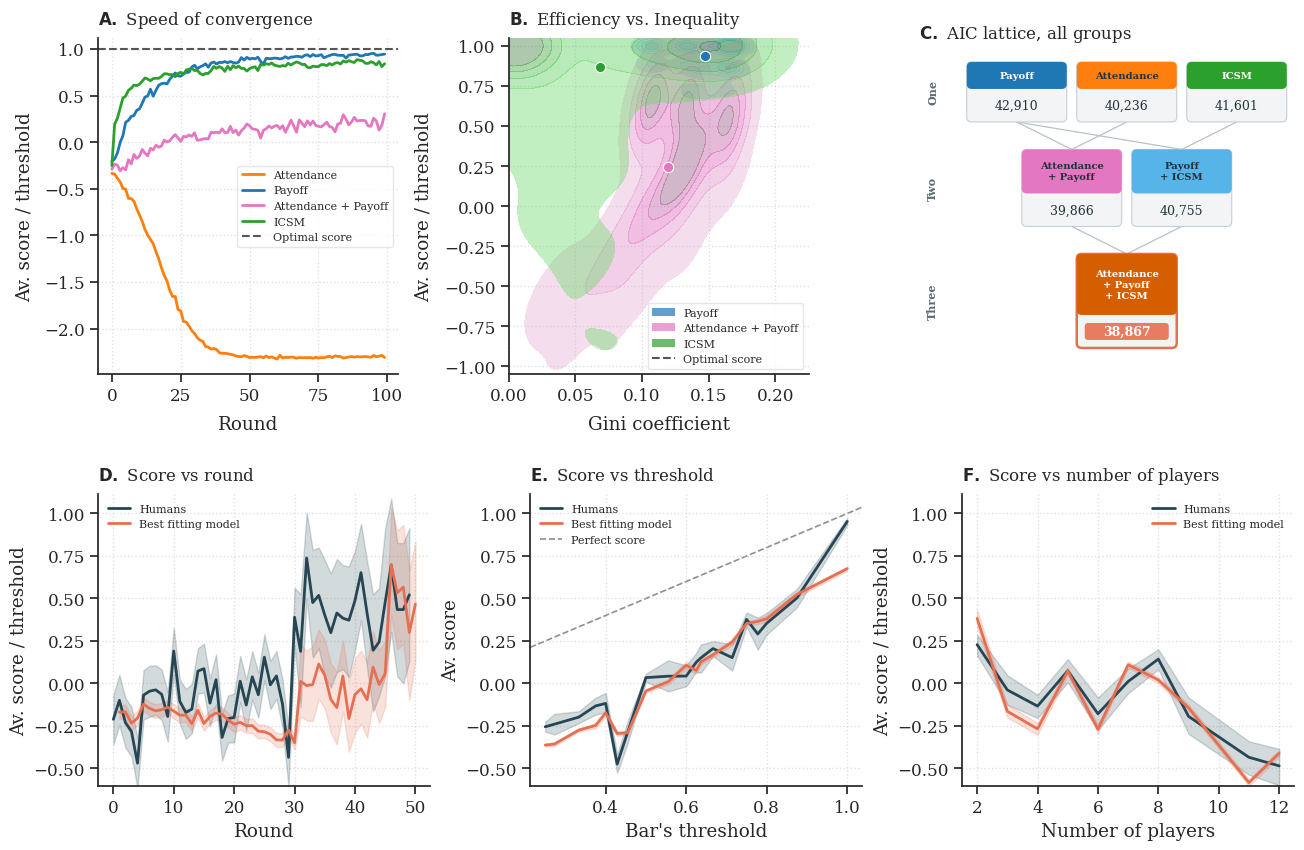

In [50]:
# 1. Global Academic Styling
sns.set_theme(style="ticks", font_scale=1.1)
plt.rcParams["font.family"] = "serif"

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# 2. Display names / palettes
model_display = {
    'Payoff-M1': 'Payoff',
    'OnlyAttendance-M1': 'Attendance',
    'ICSM': 'ICSM',
    'Attendance-M1': 'Attendance + Payoff',
    'Payoff+ICSM-M1': 'Payoff + ICSM',
    'Attendance+Payoff+ICSM-M1': 'Attendance + Payoff + ICSM',
}
# Panels A/B: same four M1 mechanisms as compare_M1_attendance_payoff.ipynb
ab_order = ['Attendance', 'Payoff', 'Attendance + Payoff', 'ICSM']
model_order = ab_order
model_palette = {name: MODEL_COLORS[name] for name in MODEL_COLORS}

REF_COLOR = '#6C757D'
SOURCE_ORDER = ['Humans', 'Best fitting model']
SOURCE_PALETTE = {
    'Humans': '#264653',
    'Best fitting model': '#E76F51',
}

df2_plot = df2.copy()
df2_plot['model'] = df2_plot['model'].map(model_display)
df2_plot = df2_plot[df2_plot['model'].isin(ab_order)]
data_plot = data.copy()
data_plot['model'] = data_plot['model'].map(model_display)
data_plot = data_plot[data_plot['model'].isin(ab_order)]

# Single figure: row 1 = mechanisms + AIC lattice, row 2 = human vs best fit
fig = plt.figure(figsize=(13, 8.6))
gs = gridspec.GridSpec(
    2, 1, figure=fig,
    height_ratios=[1.15, 1],
    hspace=0.38,
    top=0.95, bottom=0.08, left=0.06, right=0.98,
)
gs_top = gs[0].subgridspec(1, 3, width_ratios=[1, 1, 1.25], wspace=0.34)
gs_bot = gs[1].subgridspec(1, 3, wspace=0.30)

ax_A = fig.add_subplot(gs_top[0, 0])
ax_B = fig.add_subplot(gs_top[0, 1])
ax_C = fig.add_subplot(gs_top[0, 2])
ax_D = fig.add_subplot(gs_bot[0, 0])
ax_E = fig.add_subplot(gs_bot[0, 1])
ax_F = fig.add_subplot(gs_bot[0, 2])

# =====================================================================
# ROW 1 — A: Speed of convergence
# =====================================================================
sns.lineplot(
    x='round', y='bounded_score', hue='model',
    hue_order=ab_order, palette=model_palette,
    linewidth=2, errorbar=None, data=df2_plot, ax=ax_A,
    legend=True,
)
ax_A.axhline(
    y=1, color='#555555', linestyle='--',
    linewidth=1.5, label='Optimal score',
)
ax_A.set_xlabel('Round', labelpad=8)
ax_A.set_ylabel('Av. score / threshold', labelpad=8)
ax_A.set_title(r"$\bf{A.}$ Speed of convergence", loc='left', pad=10, fontsize=12)
ax_A.legend(
    loc='best',
    frameon=True,
    facecolor='white',
    edgecolor='#e0e0e0',
    fontsize=8,
    title=None,
)

# =====================================================================
# ROW 1 — B: Efficiency vs. Inequality
# =====================================================================
for lab in ab_order:
    if lab == 'Attendance':
        continue
    subset = data_plot[data_plot['model'] == lab]
    sns.kdeplot(
        x='gini_index', y='bounded_efficiency',
        data=subset, ax=ax_B,
        color=model_palette[lab],
        fill=True, alpha=0.4, levels=6, thresh=0.05,
        warn_singular=False, legend=False,
    )
    ax_B.scatter(
        subset['gini_index'].mean(),
        subset['bounded_efficiency'].mean(),
        color=model_palette[lab],
        edgecolors='white',
        linewidths=0.8,
        s=55,
        zorder=5,
    )
ax_B.set_xlabel('Gini coefficient', labelpad=8)
ax_B.set_ylabel('Av. score / threshold', labelpad=8)
ax_B.set_xlim(0, 0.225)
ax_B.set_ylim(-1.05, 1.05)
ax_B.set_title(r"$\bf{B.}$ Efficiency vs. Inequality", loc='left', pad=10, fontsize=12)
ax_B.legend(
    handles=[
        Patch(facecolor=model_palette[lab], edgecolor='none', alpha=0.7, label=lab)
        for lab in ab_order if lab != 'Attendance'
    ] + [
        Line2D([0], [0], color='#555555', linestyle='--', linewidth=1.5, label='Optimal score'),
    ],
    loc='lower right',
    frameon=True,
    facecolor='white',
    edgecolor='#e0e0e0',
    fontsize=8,
)

# =====================================================================
# ROW 1 — C: AIC lattice (all groups)
# =====================================================================
draw_aic_lattice(ax_C, aic_all_generic)
ax_C.set_title(r"$\bf{C.}$ AIC lattice, all groups", loc='left', pad=10, fontsize=12)

# =====================================================================
# ROW 2 — D: Score vs round
# =====================================================================
sns.lineplot(
    x='round', y='score_norm', hue='source',
    data=plot_df, ax=ax_D,
    hue_order=SOURCE_ORDER, palette=SOURCE_PALETTE,
    linewidth=2, errorbar=('ci', 95),
)
ax_D.set_xlabel('Round')
ax_D.set_ylabel('Av. score / threshold')
ax_D.set_title(r"$\bf{D.}$ Score vs round", loc='left', pad=10, fontsize=12)
ax_D.legend(frameon=False, fontsize=8, title=None)

# =====================================================================
# ROW 2 — E: Score vs threshold
# =====================================================================
sns.lineplot(
    x='threshold', y='score', hue='source',
    data=plot_df, ax=ax_E,
    hue_order=SOURCE_ORDER, palette=SOURCE_PALETTE,
    linewidth=2, errorbar=('ci', 95),
)
x_lo, x_hi = ax_E.get_xlim()
ax_E.plot(
    [x_lo, x_hi], [x_lo, x_hi],
    color=REF_COLOR, linestyle='--', linewidth=1.2, alpha=0.8, zorder=0,
    label='Perfect score',
)
ax_E.set_xlim(x_lo, x_hi)
ax_E.set_xlabel("Bar's threshold")
ax_E.set_ylabel('Av. score')
ax_E.set_title(r"$\bf{E.}$ Score vs threshold", loc='left', pad=10, fontsize=12)
ax_E.legend(frameon=False, fontsize=8, title=None)

# =====================================================================
# ROW 2 — F: Score vs number of players
# =====================================================================
sns.lineplot(
    x='num_agents', y='score_norm', hue='source',
    data=plot_df, ax=ax_F,
    hue_order=SOURCE_ORDER, palette=SOURCE_PALETTE,
    linewidth=2, errorbar=('ci', 95),
)
ax_F.set_xlabel('Number of players')
ax_F.set_ylabel('Av. score / threshold')
ax_F.set_title(r"$\bf{F.}$ Score vs number of players", loc='left', pad=10, fontsize=12)
ax_F.set_ylim(ax_E.get_ylim())
ax_D.set_ylim(ax_E.get_ylim())
ax_F.legend(frameon=False, fontsize=8, title=None)

for ax in [ax_A, ax_B, ax_D, ax_E, ax_F]:
    ax.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
    ax.set_axisbelow(True)
    sns.despine(ax=ax)

plt.show()


In [51]:
fig.savefig(PATHS['exploratory_figures'] / 'Fig5.png', dpi=300, bbox_inches='tight')